In [1]:
import torch
from torchvision.transforms.v2 import RandomHorizontalFlip as rhflip, RandomVerticalFlip as rvflip
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
# global_path = "/Users/edabier/Documents/Thèse/Thèse_Télécom"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.mod

Using device: cuda:0


In [15]:
dataset = "samson"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
Y_init_n = utils.standardise(Y_init)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")

features: torch.Size([1024, 196])


### Classic feature fusion

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.169, NMSE = 0.111
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.169, NMSE = 0.119
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.165, NMSE = 0.132
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.160, NMSE = 0.133
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.157, NMSE = 0.134
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.159, NMSE = 0.139
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.170, NMSE = 0.129

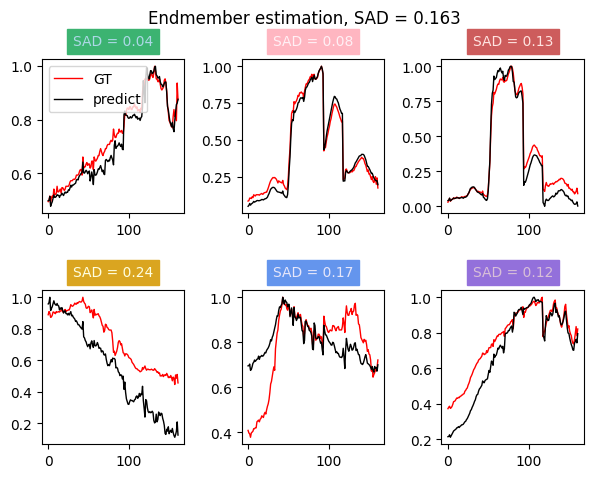

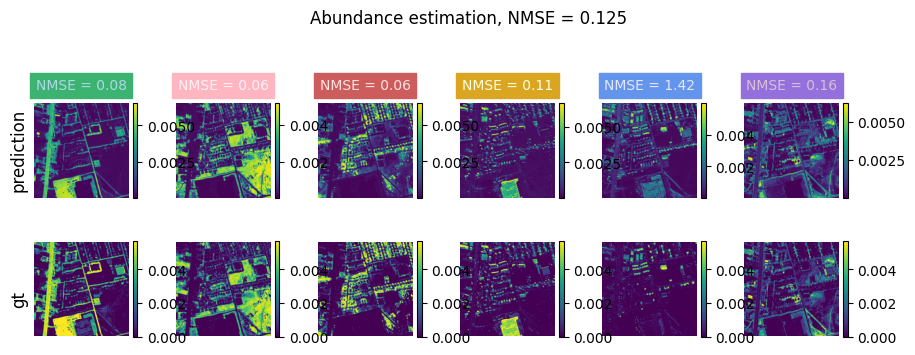

In [ ]:
"""Linear upsampling of feature"""

n_xp = 10
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)
downsample = nn.AdaptiveAvgPool2d((alpha, alpha))

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D, H=new_H, B=B, c=c, alpha=alpha, upsampler="Features_fusion")
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            Y_n = utils.standardise(Y)
            _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
        E_hat, A_hat, _ = model(features, Y_fm)
        upsampled_features[i] = model.upsample(utils.oneD_to_2d(features).unsqueeze(0), Y_fm)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

### Not using FM features

In [5]:
class FeaturesFusionUpsampler_ablation(nn.Module):
    def __init__(self, C, B, H):
        super().__init__()
        self.C = C
        self.B = B
        self.H = H

        # Step 1 : Extract features from high-res tensor (B channels)
        self.extract_hr = nn.Conv2d(B, C, kernel_size=1)  # Project B to C channels

        # Step 2 : Fuse upsampled low-res and high-res features
        self.fuse = nn.Sequential(
            nn.Conv2d(C, C, kernel_size=3, padding=1, groups=C),  # Concatenate and fuse
            nn.BatchNorm2d(C),
            nn.LeakyReLU(0.01),
        )

    def forward(self, x_hr):
        
        # Extract features from high-res tensor
        x_hr_feat = self.extract_hr(x_hr)  # (batch, C, H, H)

        # Fuse by concatenation
        x_fused = self.fuse(x_hr_feat)  # (batch, C, H, H)

        return x_fused

In [ ]:
class UnmixingFromFeatures(nn.Module):
    def __init__(self, D, B, c, H=224, upsampler="Linear"):
        """
        Upsamples low res features then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi
            alpha (int): The size of the features
            n_features (int): The size of the list of features in the case of several extracted features

        """
        super(UnmixingFromFeatures, self).__init__()
        self.D = D
        self.B = B
        self.c = c
        self.H = H
        self.upsampler = upsampler

        # Upsampling features
        if upsampler == "Linear":
            self.upsample = nn.Linear(self.alpha**2, self.H**2, bias=False)
        elif upsampler == "Features_fusion":
            self.upsample = FeaturesFusionUpsampler_ablation(D, B, H)
        else:
            raise "Unknown upsampler, must be one of [Linear, Features_fusion]"

        # Upsampled features to abundances
        self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, 1)

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Abundances and endmembers regularisation"""

        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        """Feature regularisation"""

        loss = loss_sad + loss_ab + loss_tv_e + loss_mse

        if return_losses:
            return loss, loss_sad, loss_ab, loss_tv_e, loss_mse
        else:
            return loss

    def get_abundances(self, Y):

        features_up = self.upsample(Y)
        features_up = features_up.view(
            1, self.D, self.H, self.H
        )
        features_up = (features_up - features_up.mean())/ (1e-8 + features_up.std())
        A_hat = self.abundance_estimator(features_up)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, Y):
        A_hat = self.get_abundances(Y)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.155, NMSE = 0.136
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.157, NMSE = 0.116
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.154, NMSE = 0.117
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.160, NMSE = 0.122
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.162, NMSE = 0.125
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.155, NMSE = 0.133
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.153, NMSE = 0.127

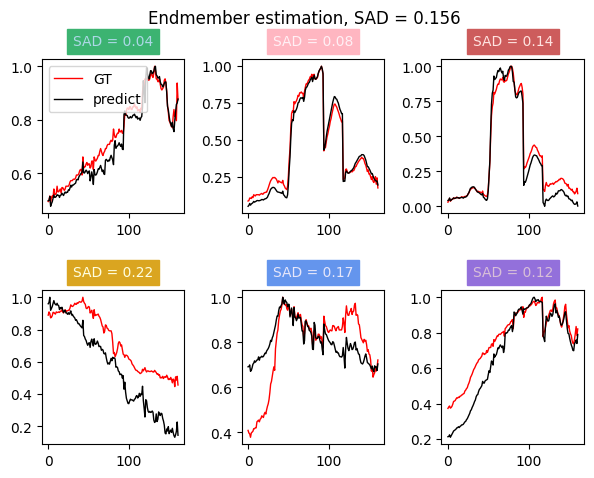

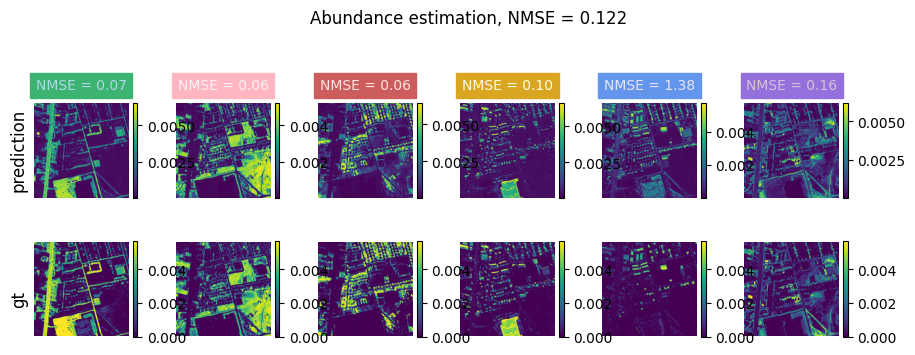

In [ ]:
"""Linear upsampling of feature"""

n_xp = 10
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)
downsample = nn.AdaptiveAvgPool2d((alpha, alpha))

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeatures(D=D, H=new_H, B=B, c=c, upsampler="Features_fusion")
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

            E_hat, A_hat, Y_hat = model(Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        
        Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
        E_hat, A_hat, _ = model(Y_fm)
        upsampled_features[i] = model.upsample(Y_fm)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

### Not using input HSI

In [10]:
class FeaturesFusionUpsampler_ablation2(nn.Module):
    def __init__(self, C, H, alpha):
        super().__init__()

        # Step 1: Upsample low-res tensor (C channels) to (batch, C, H, H)
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=H // alpha, mode='bilinear', align_corners=False),
            nn.Conv2d(C, C, kernel_size=3, padding=1),
        )

        # Step 3: Fuse upsampled low-res and high-res features
        self.fuse = nn.Sequential(
            nn.Conv2d(C, C, kernel_size=3, padding=1),  # Concatenate and fuse
            nn.BatchNorm2d(C),
            nn.LeakyReLU(0.01),
        )

    def forward(self, x_lr):
        
        x_upsampled = self.upsample(x_lr)  # (batch, C, H, H)

        # Fuse by concatenation
        x_fused = self.fuse(x_upsampled)  # (batch, C, H, H)

        return x_fused

In [11]:
class UnmixingFromFeatures2(nn.Module):
    def __init__(self, D, B, c, alpha, H=224, upsampler="Linear"):
        """
        Upsamples low res features then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi
            alpha (int): The size of the features
            n_features (int): The size of the list of features in the case of several extracted features

        """
        super(UnmixingFromFeatures2, self).__init__()
        self.D = D
        self.B = B
        self.c = c
        self.H = H
        self.alpha = alpha
        self.upsampler = upsampler

        # Upsampling features
        if upsampler == "Linear":
            self.upsample = nn.Linear(self.alpha**2, self.H**2, bias=False)
        elif upsampler == "Features_fusion":
            self.upsample = FeaturesFusionUpsampler_ablation2(D, H, alpha)
        else:
            raise "Unknown upsampler, must be one of [Linear, Features_fusion]"

        # Upsampled features to abundances
        self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, 1)

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Abundances and endmembers regularisation"""

        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        """Feature regularisation"""

        loss = loss_sad + loss_ab + loss_tv_e + loss_mse

        if return_losses:
            return loss, loss_sad, loss_ab, loss_tv_e, loss_mse
        else:
            return loss

    def get_abundances(self, features):

        features = utils.oneD_to_2d(features).unsqueeze(0)
        features_up = self.upsample(features)
        features_up = features_up.view(
            1, self.D, self.H, self.H
        )
        features_up = (features_up - features_up.mean())/ (1e-8 + features_up.std())
        A_hat = self.abundance_estimator(features_up)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features):
        A_hat = self.get_abundances(features)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.034, NMSE = 0.057
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.036, NMSE = 0.068
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.034, NMSE = 0.058
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.034, NMSE = 0.051
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.034, NMSE = 0.048
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.033, NMSE = 0.048
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.036, NMSE = 0.057

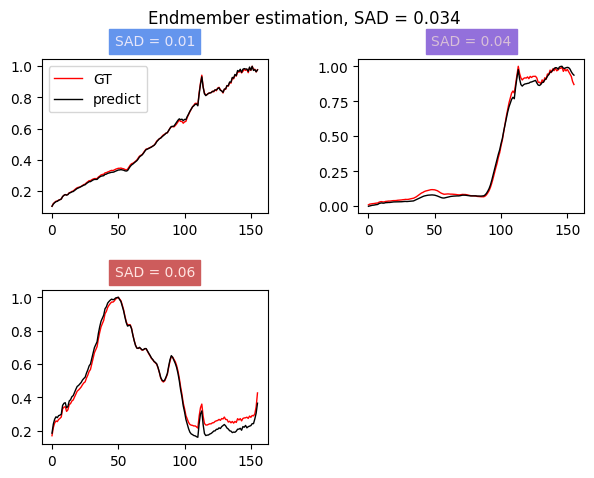

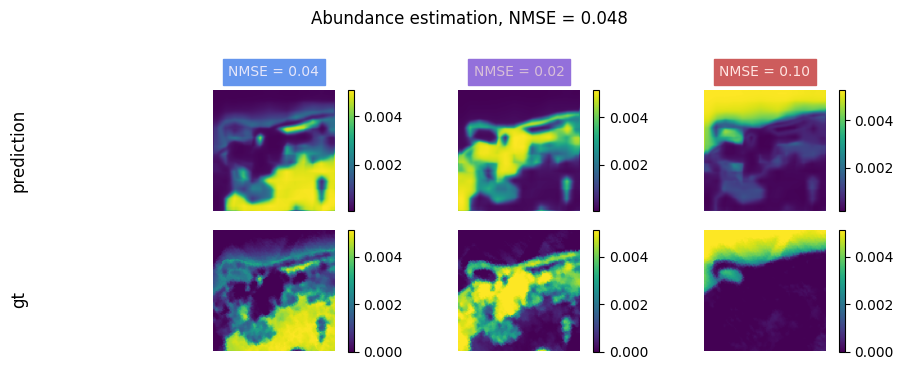

In [ ]:
"""Linear upsampling of feature"""

n_xp = 10
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)
downsample = nn.AdaptiveAvgPool2d((alpha, alpha))

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeatures2(D=D, H=new_H, B=B, c=c, alpha=alpha, upsampler="Features_fusion")
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            Y_n = utils.standardise(Y)
            _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

            E_hat, A_hat, Y_hat = model(features)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
        E_hat, A_hat, _ = model(features)
        upsampled_features[i] = model.upsample(utils.oneD_to_2d(features).unsqueeze(0))

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")